## Example application using centroid residuals from ``ska_trend.centroid_dashboard``

This is a simple demonstration reading centroid residuals from every available
observation in 2024:001 to 2026:001. It then computes some statistics on the first
500 seconds of each slot-observation and plots centroid residuals for a couple of
outliers.

Reading all the data for 2 years into memory takes just over 2 seconds on a laptop.
Doing statistics can vary but will typically be less than a second.

### Caveat about periods of not-tracking

One caveat in the data is that, like the analogous 
`chandra_aca.centroid_resid.CentroidResiduals` object, the ``CentroidResidualsLite``
object here includes only valid centroids from when the star is tracking. However, due
to the compressed storage of the centroid residuals, the `yag_times` and `zag_times`
will not include the corresponding gap in times when the star was not tracked. Instead
the times are just linear with sample number.

A future plan is to include NaN placeholders for non-track readouts, but for many
applications this issue is not really a problem.

In [1]:
import sys

# Use parent dir for ska_trend import
sys.path.insert(0, "..")

import astropy.table as apt
import kadi.commands as kc
import matplotlib.pyplot as plt
import matplotlib.style
import numpy as np

matplotlib.style.use("bmh")

import ska_trend.centroid_dashboard.app as cent_app


In [2]:
plt.rcParams["figure.dpi"] = 72  # Lower DPI
plt.rcParams["savefig.dpi"] = 72  # Lower DPI for saved figures
%config InlineBackend.figure_format = 'jpg'

In [3]:
start = "2024:001"
stop = "2026:001"
obss = kc.get_observations(start=start, stop=stop)

In [4]:
def get_frac_above_threshold(
    cr: cent_app.CentroidResidualsLite,
    threshold: float = 5.0,
    duration: float = 500.0,
):
    """Fraction of dyags or dzags above threshold in the first duration seconds.

    This is an example statistic.
    """
    i1 = np.searchsorted(cr.yag_times, duration + cr.yag_times[0])
    ok0 = np.abs(cr.dyags[:i1]) > threshold
    ok1 = np.abs(cr.dzags[:i1]) > threshold
    return np.count_nonzero(ok0 | ok1) / i1

In [5]:
def get_crs_for_obss(
    obss,
    log_missing=False,
) -> dict[tuple[int, str], cent_app.CentroidResidualsLite]:
    """Read all available centroid residuals for ``obss``.

    It is assumed ``obss`` is a list of observations from
    ``kadi.commands.get_observations``.
    """
    outs = {}
    for obs in obss:
        if "starcat_date" not in obs:
            continue

        try:
            crs = cent_app.get_centroid_resids_for_obsid(
                obsid_sched=obs["obsid_sched"], source=obs["source"]
            )
        except FileNotFoundError:
            if log_missing:
                print(f"Missing {obs['obsid_sched']} {obs['source']}")
            continue

        key = (obs["obsid_sched"], obs["source"])
        outs[key] = crs

    return outs


In [6]:
def get_stats_for_crs(
    crs_dict: dict[tuple[int, str], cent_app.CentroidResidualsLite],
    duration: float = 500.0,
) -> apt.Table:
    """Calculate statistics for a list of centroid residuals."""
    outs = []
    for (obsid_sched, source), crs in crs_dict.items():
        for slot, cr in crs.items():
            out = {
                "obsid_sched": obsid_sched,
                "source": source,
                "slot": slot,
                "frac_dyz_gt_3": get_frac_above_threshold(
                    cr, threshold=3.0, duration=duration
                ),
                "frac_dyz_gt_5": get_frac_above_threshold(
                    cr, threshold=5.0, duration=duration
                ),
            }
        outs.append(out)
    return apt.Table(rows=outs)


In [7]:
crs_obss = get_crs_for_obss(obss, log_missing=True)


Missing 29211 JAN2324B
Missing 28654 JUN0925A
Missing 30459 JUN0925A
Missing 29619 JUN0925A
Missing 42352 JUN0925A
Missing 42351 JUN0925A
Missing 42350 JUN0925A


In [8]:
stats = get_stats_for_crs(crs_obss)

In [9]:
stats.info

<Table length=4687>
     name      dtype 
------------- -------
  obsid_sched   int64
       source    str8
         slot   int64
frac_dyz_gt_3 float64
frac_dyz_gt_5 float64

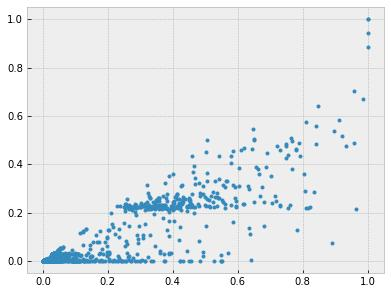

In [10]:
plt.plot(stats["frac_dyz_gt_3"], stats["frac_dyz_gt_5"], ".")

In [11]:
ok = np.abs(stats["frac_dyz_gt_5"] - 0.5) < 0.1
sok = stats[ok]
s0 = sok[0]
s0

obsid_sched,source,slot,frac_dyz_gt_3,frac_dyz_gt_5
int64,str8,int64,float64,float64
29147,DEC2523B,7,0.9569672131147541,0.48975409836065575


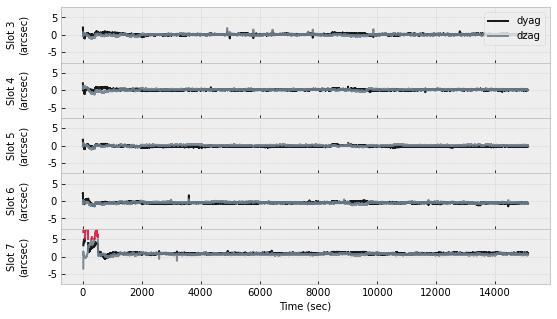

In [12]:
cent_app.plot_crs_time(crs_obss[s0["obsid_sched"], s0["source"]])

In [13]:
ok = stats["frac_dyz_gt_5"] > 0.8
s1 = stats[ok][0]
s1

obsid_sched,source,slot,frac_dyz_gt_3,frac_dyz_gt_5
int64,str8,int64,float64,float64
29302,MAR0624A,7,1.0,0.8852459016393442


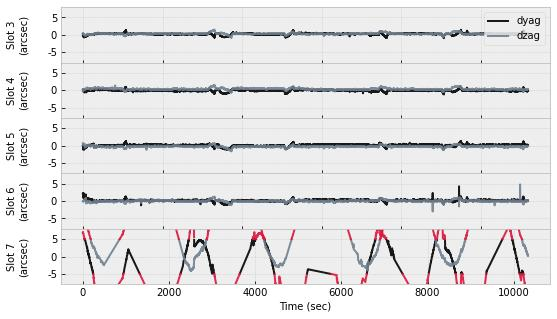

In [14]:
cent_app.plot_crs_time(crs_obss[s1["obsid_sched"], s1["source"]])